# Room-Temperature C-V Physical Modeling


In [1]:
# Import the C-V data, Cgd PINN, and physical capacitance equations.
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from CV_DeviceData import load_cv_characteristics
from physics_loss import physics_loss
from CV_CgdSurfacePotential import DeltaPhiGdPINN, phi_gd_surface, save_cgd_pinn_pkl
from CVModeling import Cgd, Cds, Cgs, built_in_potential_4h_sic
from CVPhysicalModel import CVPhysicalParameters, save_cv_physical_pkl


## Data and constants

In [2]:
# Load the room-temperature low-voltage and 0-1000 V capacitance datasets.
device = torch.device("cpu")
dtype = torch.float32
torch.manual_seed(42)
BASE_DIR = Path.cwd()
TEMPLATE_DIR = BASE_DIR / "Template"
cv_data = load_cv_characteristics(TEMPLATE_DIR)
print(cv_data.groupby(["capacitance", "range"]).size())
print("Measured Vds range =", cv_data["Vds"].min(), "to", cv_data["Vds"].max(), "V")
assert np.allclose(cv_data["T_C"].to_numpy(), 25.0)


capacitance  range
Ciss         high     19
             low      23
Coss         high     31
             low      37
Crss         high     45
             low      52
dtype: int64
Measured Vds range = 0.0 to 999.9999999999998 V


In [3]:
# Use the room-temperature surface-potential and capacitance parameters as initial physical values.
T = 298.15
NA = 1.0e16
Eg = 3.26
eps_sic = 9.26 * 8.854e-14
Cox = 7.0e-8
Qox = 1.602e-7
Vfbs0 = -1.0
Dit_mid = 2.0e11
Dit_edge = 2.0e13
sigma_it = 0.1
Ec_minus_Ei = Eg / 2.0

VGD_MIN = -1000.0
VGD_MAX = 0.0
VDS_MIN = 0.0
VDS_MAX = 1000.0
CGD_PRETRAINED_PKL = BASE_DIR / "Cgd_PINN_pretrained.pkl"
CGD_PKL = BASE_DIR / "Cgd_PINN.pkl"
CV_PKL = BASE_DIR / "CV_physical_25C.pkl"


## Pretrain the room-temperature Cgd surface-potential PINN


In [4]:
# Train phi_gd at 25 C with Vgd = Vgs - Vds and Vds as the quasi-Fermi potential.
Model_Cgd = DeltaPhiGdPINN(VGD_MIN, VGD_MAX, VDS_MIN, VDS_MAX).to(device=device, dtype=dtype)

N_RANDOM = 7000

Vds_random = VDS_MAX * torch.rand(N_RANDOM, 1, dtype=dtype, device=device)
Vgd_random = VGD_MIN + (VGD_MAX - VGD_MIN) * torch.rand(N_RANDOM, 1, dtype=dtype, device=device)

Vds_line = torch.linspace(0.0, 1000.0, 1201, dtype=dtype, device=device).reshape(-1, 1)
Vgd_line = -Vds_line

Vds_train = torch.cat([Vds_random, Vds_line], dim=0)
Vgd_train = torch.cat([Vgd_random, Vgd_line], dim=0)

N_TRAIN = len(Vds_train)

EPOCHS_GD = 3000
BATCH_SIZE_GD = 512
LEARNING_RATE_GD = 1.0e-4

optimizer_gd = torch.optim.Adam(Model_Cgd.parameters(), lr=LEARNING_RATE_GD)

best_loss_gd = float("inf")
best_state_gd = None
loss_gd_history = []

for epoch in range(EPOCHS_GD):
    permutation = torch.randperm(N_TRAIN, device=device)
    epoch_loss = 0.0
    batches = 0

    Model_Cgd.train()

    for start in range(0, N_TRAIN, BATCH_SIZE_GD):
        idx = permutation[start:start + BATCH_SIZE_GD]

        Vgd_batch = Vgd_train[idx]
        Vds_batch = Vds_train[idx]

        optimizer_gd.zero_grad(set_to_none=True)

        phigd = phi_gd_surface(Model_Cgd, Vgd_batch, Vds_batch, T=T, NA=NA, eps_sic=eps_sic, Cox=Cox, Vfbs0=Vfbs0, Dit_mid=Dit_mid, Dit_edge=Dit_edge, sigma_it=sigma_it, Eg=Eg)

        loss = physics_loss(phigd, Vgd_batch, Vds_batch, T, NA, eps_sic, Cox, Vfbs0, Qox, Dit_mid, Dit_edge, sigma_it, Ec_minus_Ei, Eg)

        if not torch.isfinite(loss):
            raise RuntimeError(f"Non-finite Cgd PINN loss at epoch {epoch}")

        loss.backward()

        torch.nn.utils.clip_grad_norm_(Model_Cgd.parameters(), max_norm=10.0)

        optimizer_gd.step()

        epoch_loss += loss.item()
        batches += 1

    epoch_loss /= batches
    loss_gd_history.append(epoch_loss)

    if epoch_loss < best_loss_gd:
        best_loss_gd = epoch_loss
        best_state_gd = {k: v.detach().cpu().clone() for k, v in Model_Cgd.state_dict().items()}

    if epoch % 100 == 0 or epoch == EPOCHS_GD - 1:
        print(f"Cgd PINN epoch {epoch:4d} | L_SPE = {epoch_loss:.6e}")

Model_Cgd.load_state_dict(best_state_gd, strict=True)
Model_Cgd.eval()

# Freeze the trained Cgd surface-potential PINN.
for parameter in Model_Cgd.parameters():
    parameter.requires_grad_(False)

save_cgd_pinn_pkl(CGD_PRETRAINED_PKL, Model_Cgd, physical_parameters={"T_K": T, "NA": NA, "Cox": Cox, "Vfbs0": Vfbs0, "Dit_mid": Dit_mid, "Dit_edge": Dit_edge, "sigma_it": sigma_it, "Eg": Eg}, training_metadata={"best_PI_loss": best_loss_gd, "epochs": EPOCHS_GD})

print("Saved =", CGD_PRETRAINED_PKL.name)

Cgd PINN epoch    0 | L_SPE = 7.144414e+00
Cgd PINN epoch  100 | L_SPE = 5.541998e-02
Cgd PINN epoch  200 | L_SPE = 5.727975e-02
Cgd PINN epoch  300 | L_SPE = 1.691932e-02
Cgd PINN epoch  400 | L_SPE = 3.845703e-02
Cgd PINN epoch  500 | L_SPE = 2.641661e-02
Cgd PINN epoch  600 | L_SPE = 2.622011e-02
Cgd PINN epoch  700 | L_SPE = 2.713639e-02
Cgd PINN epoch  800 | L_SPE = 5.610432e-02
Cgd PINN epoch  900 | L_SPE = 4.525717e-02
Cgd PINN epoch 1000 | L_SPE = 2.627775e-02
Cgd PINN epoch 1100 | L_SPE = 2.665231e-02
Cgd PINN epoch 1200 | L_SPE = 2.523416e-02
Cgd PINN epoch 1300 | L_SPE = 2.723957e-02
Cgd PINN epoch 1400 | L_SPE = 5.218987e-02
Cgd PINN epoch 1500 | L_SPE = 5.288647e-02
Cgd PINN epoch 1600 | L_SPE = 2.484309e-02
Cgd PINN epoch 1700 | L_SPE = 2.611817e-02
Cgd PINN epoch 1800 | L_SPE = 2.628625e-02
Cgd PINN epoch 1900 | L_SPE = 2.619092e-02
Cgd PINN epoch 2000 | L_SPE = 2.608946e-02
Cgd PINN epoch 2100 | L_SPE = 2.667648e-02
Cgd PINN epoch 2200 | L_SPE = 2.423526e-02
Cgd PINN ep

## Fit the room-temperature physical C-V parameters with automatic differentiation


In [5]:
# Convert all measured capacitance points to tensors and type labels.
Vds_data = torch.tensor(cv_data["Vds"].to_numpy(np.float32), dtype=dtype, device=device).reshape(-1, 1)
C_measured_pF = torch.tensor(cv_data["Capacitance_pF"].to_numpy(np.float32), dtype=dtype, device=device).reshape(-1, 1)
cap_codes = {"Ciss": 0, "Coss": 1, "Crss": 2}
cap_type = torch.tensor([cap_codes[name] for name in cv_data["capacitance"]], dtype=torch.long, device=device).reshape(-1, 1)
cv_parameters = CVPhysicalParameters(ND=5.0e16).to(device=device, dtype=dtype)


In [6]:
# Evaluate Ciss, Coss, and Crss using the fixed Cgd PINN and physical capacitance equations.

def evaluate_cv(Vds):
    values = cv_parameters.values(Cox)

    Vds_eff = torch.minimum(torch.clamp(Vds, min=0.0), values["Vpt"])
    Vgd_eff = -Vds_eff

    phigd = phi_gd_surface(Model_Cgd, Vgd_eff, Vds_eff, T=T, NA=NA, eps_sic=eps_sic, Cox=Cox, Vfbs0=Vfbs0, Dit_mid=Dit_mid, Dit_edge=Dit_edge, sigma_it=sigma_it, Eg=Eg)

    Vbi = built_in_potential_4h_sic(T, NA, values["ND"], Eg, Vds)

    Cgd_value = Cgd(phigd, Vds_eff, T, NA, values["ND"], Eg, eps_sic, values["Agd"], values["Coxgd"])
    Cds_value = Cds(Vds, values["ND"], eps_sic, values["Ads"], Vbi, values["Vpt"])
    Cgs_value = Cgs(Vds, values["Cgs_const"])

    Ciss = Cgs_value + Cgd_value
    Coss = Cds_value + Cgd_value
    Crss = Cgd_value

    return Ciss, Coss, Crss, phigd, Vgd_eff

In [7]:
# Evaluate the C-V model without additional neural-network training.

Model_Cgd.eval()
cv_parameters.eval()

with torch.no_grad():
    Ciss, Coss, Crss, phigd, Vgd_eff = evaluate_cv(Vds_data)

    all_pred_pF = torch.cat([Ciss * 1.0e12, Coss * 1.0e12, Crss * 1.0e12], dim=1)
    C_pred_pF = torch.gather(all_pred_pF, 1, cap_type)

    data_loss = torch.mean((torch.log(torch.clamp(C_pred_pF, min=1.0e-3)) - torch.log(torch.clamp(C_measured_pF, min=1.0e-3))) ** 2)

print("C-V data loss =", data_loss.item())
print({k: float(v.item()) if torch.is_tensor(v) else v for k, v in cv_parameters.values(Cox).items()})

C-V data loss = 36.59429168701172
{'ND': 5e+16, 'Agd': 0.03150000050663948, 'Ads': 0.02969999983906746, 'Coxgd_scale': 1.0, 'Coxgd': 2.204999960397913e-09, 'Cgs_const': 1.0999992028359884e-09, 'Vpt': 800.0000610351562}


## Check which params are trained

In [8]:
# Check that the Cgd PINN and C-V physical parameters are fixed.

print("Trainable Cgd parameters:", [name for name, parameter in Model_Cgd.named_parameters() if parameter.requires_grad])
print("Trainable C-V physical parameters:", [name for name, parameter in cv_parameters.named_parameters() if parameter.requires_grad])

Trainable Cgd parameters: []
Trainable C-V physical parameters: []


## Save the final Cgd PINN and room-temperature C-V physical parameters


In [9]:
# Save the final Cgd PINN and physical C-V parameters as pkl files.

save_cgd_pinn_pkl(CGD_PKL, Model_Cgd, physical_parameters={"T_K": T, "NA": NA, "Cox": Cox, "Vfbs0": Vfbs0, "Dit_mid": Dit_mid, "Dit_edge": Dit_edge, "sigma_it": sigma_it, "Eg": Eg}, training_metadata={"temperature_C": 25.0, "best_PI_loss": best_loss_gd, "epochs": EPOCHS_GD})

save_cv_physical_pkl(CV_PKL, cv_parameters, training_metadata={"temperature_C": 25.0, "data_loss": float(data_loss.item())})

cv_bundle = {"format_version": 2, "model_name": "SiC_MOSFET_CV_25C", "temperature_C": 25.0, "Cgd_surface_PINN": torch.load(CGD_PKL, map_location="cpu", weights_only=False), "CV_physical": torch.load(CV_PKL, map_location="cpu", weights_only=False)}

torch.save(cv_bundle, BASE_DIR / "CV_Model_25C.pkl")

print("Saved Cgd_PINN.pkl, CV_physical_25C.pkl, and CV_Model_25C.pkl")

Saved Cgd_PINN.pkl, CV_physical_25C.pkl, and CV_Model_25C.pkl


## Room-temperature C-V comparison


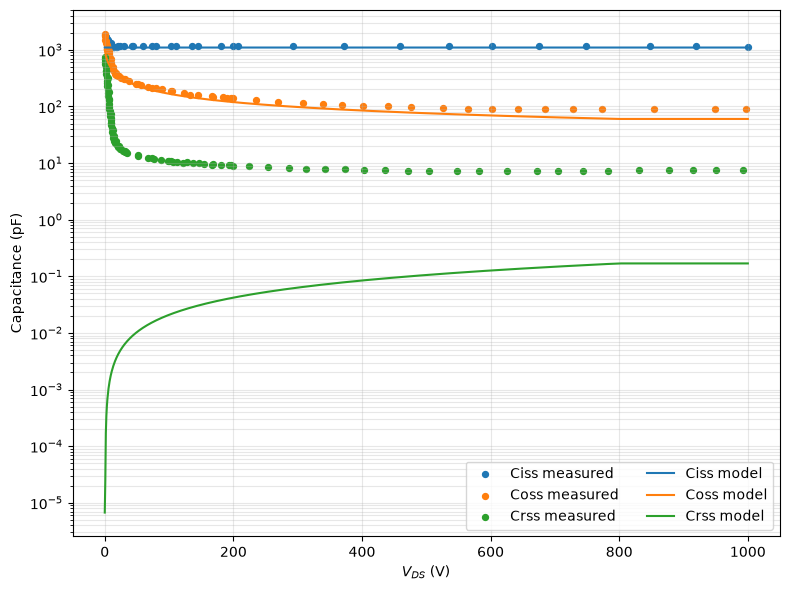

In [10]:
# Compare the fitted room-temperature Ciss, Coss, and Crss curves with both measured voltage ranges.
Vds_plot = torch.linspace(0.0, 1000.0, 1200, dtype=dtype, device=device).reshape(-1, 1)
Model_Cgd.eval()
cv_parameters.eval()
with torch.no_grad():
    Ciss_plot, Coss_plot, Crss_plot, _, _ = evaluate_cv(Vds_plot)

plt.figure(figsize=(8, 6))
for name in ["Ciss", "Coss", "Crss"]:
    part = cv_data[cv_data["capacitance"] == name]
    plt.scatter(part["Vds"], part["Capacitance_pF"], s=18, label=f"{name} measured")
for values, name in [(Ciss_plot, "Ciss model"), (Coss_plot, "Coss model"), (Crss_plot, "Crss model")]:
    plt.plot(Vds_plot.cpu(), (values * 1.0e12).cpu(), label=name)
plt.xlabel(r"$V_{DS}$ (V)")
plt.ylabel("Capacitance (pF)")
plt.yscale("log")
plt.grid(True, which="both", alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


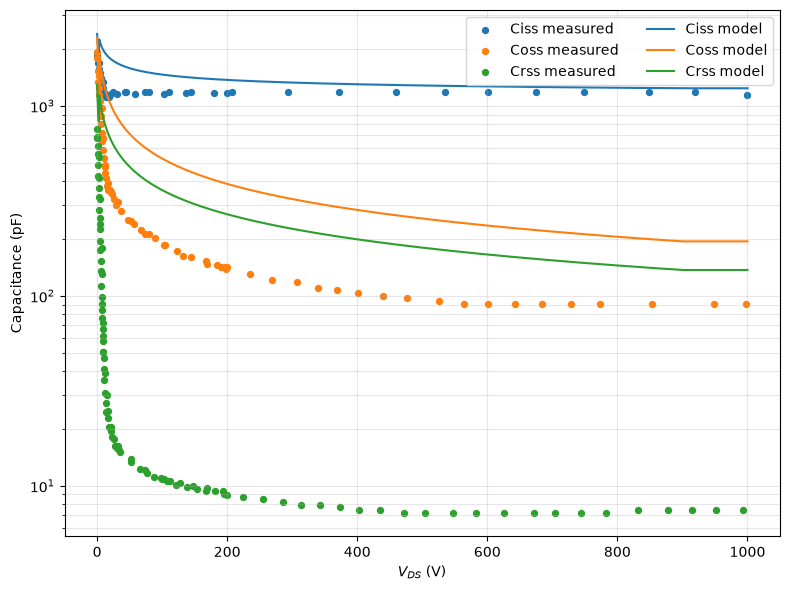

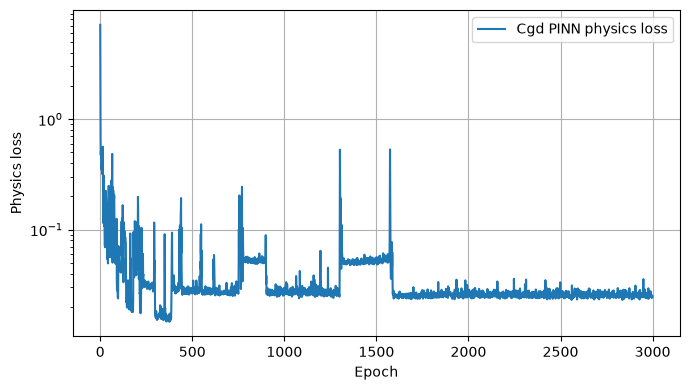

In [11]:
# Plot the room-temperature physics and C-V optimization losses.
plt.figure(figsize=(7, 4))
plt.plot(loss_gd_history, label="Cgd PINN physics loss")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Physics loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
